In [29]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Reading the CSV file and saving it into a DataFrame named 'df'
df = pd.read_csv('glass.csv')

# Checking the first 5 rows of the data
df.head()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type of glass
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [20]:
# Getting full information about the data (rows, columns, data types)
print(df.info())

print("\n--------------------------\n")

# Checking the count of each glass type in the target column ('Type of glass')
print(df['Type of glass'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             214 non-null    int64  
 1   RI             214 non-null    float64
 2   Na             214 non-null    float64
 3   Mg             214 non-null    float64
 4   Al             214 non-null    float64
 5   Si             214 non-null    float64
 6   K              214 non-null    float64
 7   Ca             214 non-null    float64
 8   Ba             214 non-null    float64
 9   Fe             214 non-null    float64
 10  Type of glass  214 non-null    int64  
dtypes: float64(9), int64(2)
memory usage: 18.5 KB
None

--------------------------

Type of glass
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [21]:
# Check for duplicate rows in the dataset
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [22]:
# Generate descriptive statistics for numerical features
summary = df.describe()

# Display the summary
display(summary)

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type of glass
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,107.500000,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,61.920648,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.000000,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,54.250000,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,107.500000,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,160.750000,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,214.000000,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


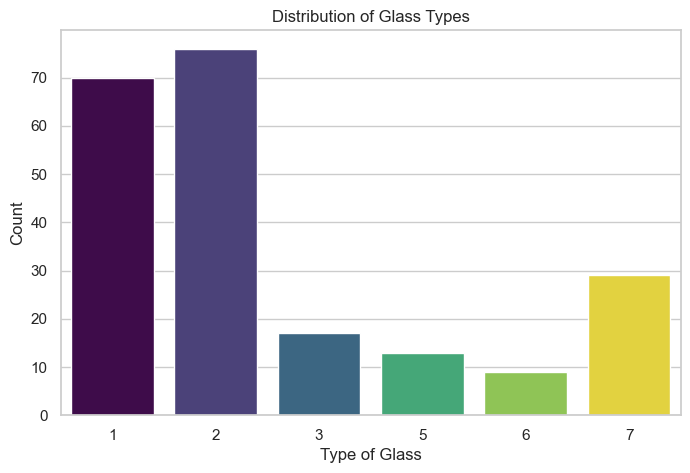

In [23]:
# Set the style of the plots
sns.set_theme(style="whitegrid")

# Create a count plot for the target variable 'Type of glass'
plt.figure(figsize=(8, 5))
sns.countplot(x='Type of glass', data=df, palette='viridis', hue='Type of glass', legend=False)
plt.title('Distribution of Glass Types')
plt.xlabel('Type of Glass')
plt.ylabel('Count')
plt.show()

In [24]:
# Drop the 'Id' column as it has no predictive power
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
    print("'Id' column dropped successfully.")
    
# Check the updated columns
print(df.columns)

'Id' column dropped successfully.
Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type of glass'], dtype='object')


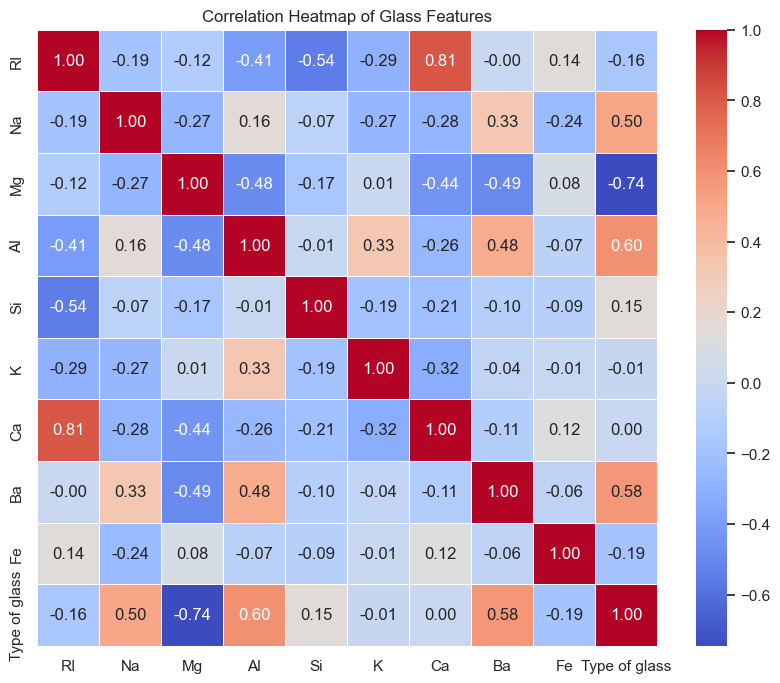

In [25]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap to visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Glass Features')
plt.show()

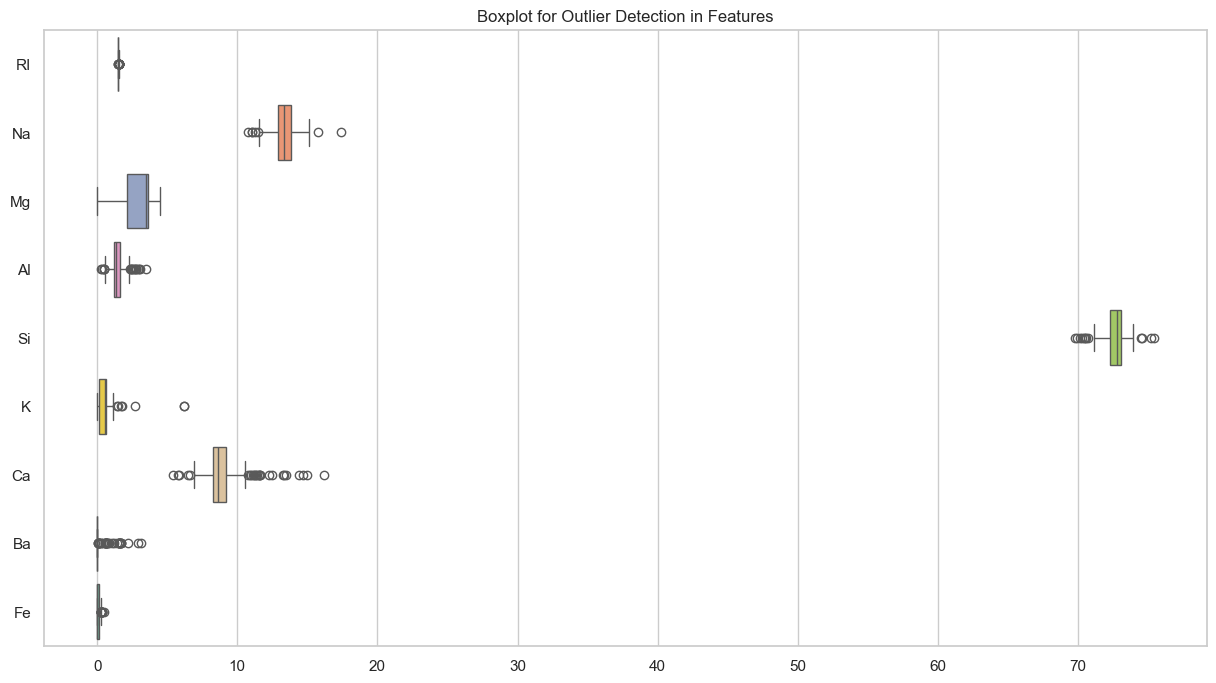

In [26]:
# Create boxplots for all features to identify outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop('Type of glass', axis=1), orient="h", palette="Set2")
plt.title('Boxplot for Outlier Detection in Features')
plt.show()

In [27]:
# Separate features (X) and target variable (y)
X = df.drop('Type of glass', axis=1)
y = df['Type of glass']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a pandas DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first few rows of the scaled data
display(X_scaled_df.head())

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451


In [28]:
# Step 1: Splitting the data into Training (80%) and Testing (20%) sets
# X_scaled_df is your cleaned/scaled data, y is the target column
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("\n--------------------------\n")

# Step 2: Initializing the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 3: Teaching the model using the training data
rf_model.fit(X_train, y_train)
print("Model training completed successfully!")

# Step 4: Making predictions on the unseen testing data
y_pred = rf_model.predict(X_test)

# Step 5: Checking the accuracy of our model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

Training data shape: (171, 9)
Testing data shape: (43, 9)

--------------------------

Model training completed successfully!

Model Accuracy: 83.72%


Classification Report:

              precision    recall  f1-score   support

           1       0.69      1.00      0.81        11
           2       0.90      0.64      0.75        14
           3       1.00      0.67      0.80         3
           5       1.00      0.75      0.86         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.84        43
   macro avg       0.91      0.84      0.86        43
weighted avg       0.87      0.84      0.83        43


--------------------------



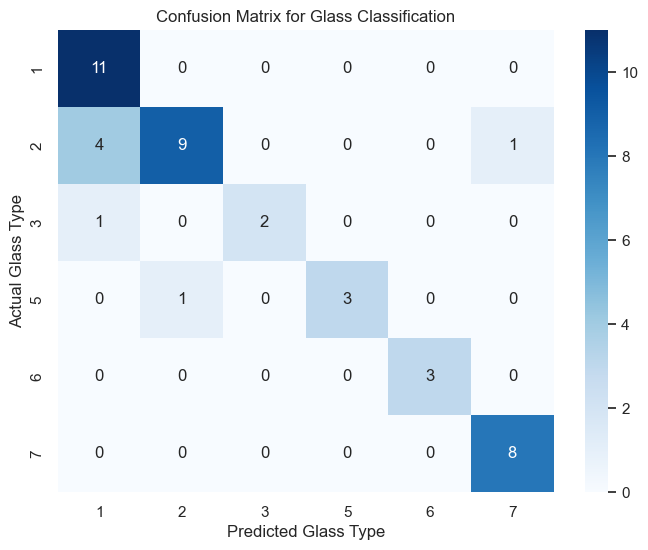

In [30]:
# 1. Classification Report generate karna
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\n--------------------------\n")

# 2. Confusion Matrix ka Heatmap banana
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
# sns.heatmap ke parameters map ko visually clean banate hain
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y_test.unique()), 
            yticklabels=sorted(y_test.unique()))

plt.title('Confusion Matrix for Glass Classification')
plt.xlabel('Predicted Glass Type')
plt.ylabel('Actual Glass Type')
plt.show()

In [31]:
# Importing SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Step 1: Initialize the SVM Model
# 'kernel=rbf' ka matlab hai ye non-linear (tedhe-medhe) patterns ko bhi samajh payega
svm_model = SVC(kernel='rbf', random_state=42)

# Step 2: Train the model
svm_model.fit(X_train, y_train)
print("SVM Model training completed!")

# Step 3: Make predictions
y_pred_svm = svm_model.predict(X_test)

# Step 4: Check Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM Model Accuracy: {accuracy_svm * 100:.2f}%")

SVM Model training completed!

SVM Model Accuracy: 72.09%


In [34]:
# Importing KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Step 1: Initialize the KNN Model
# 'n_neighbors=5' ka matlab hai ye prediction ke liye apne 5 sabse closest neighbors ko dekhega
knn_model = KNeighborsClassifier(n_neighbors=5)

# Step 2: Train the model
knn_model.fit(X_train, y_train)
print("KNN Model training completed!")

# Step 3: Make predictions
y_pred_knn = knn_model.predict(X_test)

# Step 4: Check Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nKNN Model Accuracy: {accuracy_knn * 100:.2f}%")

KNN Model training completed!

KNN Model Accuracy: 69.77%


In [35]:
# Importing Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Step 1: Initialize the Gradient Boosting Model
gb_model = GradientBoostingClassifier(random_state=42)

# Step 2: Train the model
gb_model.fit(X_train, y_train)
print("Gradient Boosting Model training completed!")

# Step 3: Make predictions
y_pred_gb = gb_model.predict(X_test)

# Step 4: Check Accuracy
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"\nGradient Boosting Model Accuracy: {accuracy_gb * 100:.2f}%")

Gradient Boosting Model training completed!

Gradient Boosting Model Accuracy: 86.05%


In [36]:
# Importing Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

# Step 1: Initialize the Extra Trees Model
et_model = ExtraTreesClassifier(n_estimators=100, random_state=42)

# Step 2: Train the model
et_model.fit(X_train, y_train)
print("Extra Trees Model training completed!")

# Step 3: Make predictions
y_pred_et = et_model.predict(X_test)

# Step 4: Check Accuracy
accuracy_et = accuracy_score(y_test, y_pred_et)
print(f"\nExtra Trees Model Accuracy: {accuracy_et * 100:.2f}%")

Extra Trees Model training completed!

Extra Trees Model Accuracy: 81.40%


In [37]:
# Importing Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 1: Initialize the Logistic Regression Model
# max_iter=1000 diya hai taaki model aaram se calculate kar sake
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Step 2: Train the model
log_model.fit(X_train, y_train)
print("Logistic Regression Model training completed!")

# Step 3: Make predictions
y_pred_log = log_model.predict(X_test)

# Step 4: Check Accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"\nLogistic Regression Model Accuracy: {accuracy_log * 100:.2f}%")

Logistic Regression Model training completed!

Logistic Regression Model Accuracy: 72.09%


🌟 Classification Report (Gradient Boosting):

              precision    recall  f1-score   support

           1       0.79      1.00      0.88        11
           2       0.92      0.79      0.85        14
           3       0.75      1.00      0.86         3
           5       1.00      0.75      0.86         4
           6       1.00      0.33      0.50         3
           7       0.89      1.00      0.94         8

    accuracy                           0.86        43
   macro avg       0.89      0.81      0.81        43
weighted avg       0.88      0.86      0.85        43


--------------------------------------------------



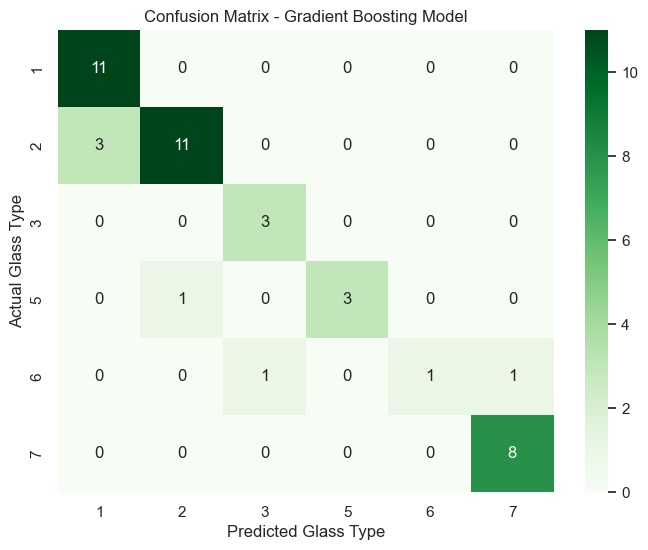

In [38]:
# 1. Classification Report for Gradient Boosting
print("🌟 Classification Report (Gradient Boosting):\n")
print(classification_report(y_test, y_pred_gb))

print("\n--------------------------------------------------\n")

# 2. Confusion Matrix Heatmap for Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 6))
# Heatmap design options
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', # Is baar thoda alag color (Greens) use karte hain
            xticklabels=sorted(y_test.unique()), 
            yticklabels=sorted(y_test.unique()))

plt.title('Confusion Matrix - Gradient Boosting Model')
plt.xlabel('Predicted Glass Type')
plt.ylabel('Actual Glass Type')
plt.show()

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Step 1: Ek "Menu" (Grid) banayenge un settings ka jo hum test karna chahte hain
param_grid = {
    'n_estimators': [50, 100, 150, 200],      # Model kitne decision trees banayega
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Model ki seekhne ki speed
    'max_depth': [3, 4, 5, 6]                 # Har tree kitna deep (gehra) hoga
}

# Step 2: Base model initialize karna
gb_base = GradientBoostingClassifier(random_state=42)

# Step 3: GridSearchCV setup karna (cv=5 ka matlab 5-Fold Cross Validation hai)
# n_jobs=-1 ka matlab hai ki ye code aapke processor ki full power use karega taaki fast chale
grid_search = GridSearchCV(estimator=gb_base, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=1)

# Step 4: Training start karna
print("⏳ Hyperparameter Tuning start ho gayi hai... (Thoda time lag sakta hai)")
grid_search.fit(X_train, y_train)

# Step 5: Best parameters nikalna
print("\n🎉 Tuning Complete!")
print(f"Sabse Best Settings (Parameters): {grid_search.best_params_}")

# Step 6: Best model se aakhri test karna
best_gb_model = grid_search.best_estimator_
y_pred_tuned = best_gb_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"\n🚀 Tuned Gradient Boosting Accuracy: {accuracy_tuned * 100:.2f}%")

⏳ Hyperparameter Tuning start ho gayi hai... (Thoda time lag sakta hai)
Fitting 5 folds for each of 64 candidates, totalling 320 fits

🎉 Tuning Complete!
Sabse Best Settings (Parameters): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

🚀 Tuned Gradient Boosting Accuracy: 86.05%


In [40]:
import joblib

# Hum apne best model (Gradient Boosting) ko save kar rahe hain
joblib.dump(gb_model, 'glass_prediction_model.pkl')

# Hum scaler ko bhi save karenge kyunki user jo naya data website par dalega, 
# usko bhi model mein dalne se pehle scale karna padega!
joblib.dump(scaler, 'glass_scaler.pkl')

print("Model and Scaler saved successfully! 🎉")

Model and Scaler saved successfully! 🎉
